# Generator-Critic — LangChain LCEL

> "The model critiques; the harness decides."

This notebook implements Generator-Critic using **LangChain Expression Language (LCEL)**:

- a generator pipe creates an `Artifact`
- a critic pipe turns that artifact into structured `Critique` evidence
- a deterministic policy gate decides `accepted` vs `needs_revision`
- an optional reviser drafts a replacement, but never auto-accepts it

In the [LangGraph version](../langgraph/tutorial.ipynb), every role is an explicit node and the branch after the gate is visible. Here the same pattern is compressed into composable runnables. Less code, less visible control flow — that is the trade-off this notebook makes concrete.

Everything runs against deterministic fake responses first (no API key needed), then the real backend. Default: AI Studio + `ernie-5.1` (OpenAI-compatible). See [`.env.example`](../../../.env.example) for provider config and [`model_config.py`](../../../model_config.py) for the shared loader.

## What this pattern does

Generator-Critic is a one-pass reflection pattern for work that must be checked before it leaves the system. The generator writes the artifact, the critic produces evidence about that artifact, and ordinary program code owns the final decision.

The crucial boundary: **the critic is not the approver**. A critic can say "looks good" or return a high score, but the harness only accepts when the parsed `Critique` satisfies the deterministic `AcceptancePolicy`. If a revision is drafted, it ends this pass as `needs_revision`; a fresh critique is required before any revised artifact can be accepted.

| | `langgraph/` (StateGraph) | `langchain/` (LCEL) |
|---|---|---|
| **The roles are** | Explicit nodes: `generate -> critique -> gate -> revise` | Runnables: generator pipe, critic pipe, policy runnable |
| **The branch is** | A conditional edge after `gate` | Code inside `make_policy_gate` |
| **Mock roles** | Plain Python callables from `shared.py` | `FakeListChatModel` responses in call order |
| **Safety boundary** | Revision drafts end the pass | Same: no auto-accept after revision |
| **Trade-off** | More code, every transition visible | Less code, control flow implicit |


## Setup

The mock cells are deterministic and need no API key. The real-backend section at the end calls `get_model()` directly; when no model is configured, it skips with a short message.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# shared.py lives in the pattern folder; model_config.py and nbtools.py live at
# the repo root. Search upward for each marker so this notebook works from
# JupyterLab, nbmake, nbconvert, or the repo root without brittle ../../ paths.
for _marker in ("shared.py", "model_config.py", "nbtools.py"):
    _dir = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / _marker).exists())
    sys.path.insert(0, str(_dir))

from langchain_core.language_models.fake_chat_models import FakeListChatModel
from langchain_core.messages import SystemMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

from model_config import get_model
from nbtools import show_graph
from pattern import Artifact, ChainResult, Decision
from shared import (
    BAD_CRITIQUE_JSON,
    CRITIC_SYSTEM_PROMPT,
    DEFAULT_PROMPT,
    GENERATOR_SYSTEM_PROMPT,
    GOOD_CRITIQUE_JSON,
    INITIAL_DRAFT,
    LOW_SCORE_CRITIQUE_JSON,
    NEEDS_REVISION_CRITIQUE_JSON,
    OPINION_ONLY_CRITIQUE_JSON,
    default_policy,
    parse_critique_json,
    print_trace,
    revise_with_evidence,
)

## The generator and critic as LCEL pipes

Each role is a small pipe. The generator pipe converts an LLM message into the core `Artifact` type; the critic pipe converts an LLM message into the core `Critique` type. Once those two boundaries are crossed, the rest of the pattern is plain Python.

The critic prompt asks for JSON, but the parser still fails closed. If the model returns malformed JSON, unknown severities, or missing fields, `parse_critique_json` creates a blocker critique instead of letting bad evidence pass.

In [2]:
def build_generator(model):
    """Build the LCEL generator role: prompt -> model -> string -> Artifact."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", GENERATOR_SYSTEM_PROMPT),
        ("human", "{prompt}"),
    ])
    return (
        prompt
        | model
        | StrOutputParser()
        # The core pattern does not know about LangChain messages. Convert at
        # the edge so the downstream gate sees the same Artifact as pattern.py.
        | RunnableLambda(lambda text: Artifact(content=text))
    )


def build_critic(model):
    """Build the LCEL critic role: Artifact text -> model -> parsed Critique."""
    prompt = ChatPromptTemplate.from_messages([
        # CRITIC_SYSTEM_PROMPT contains literal JSON braces. Passing it as a
        # concrete SystemMessage prevents ChatPromptTemplate from treating those
        # braces as template variables.
        SystemMessage(content=CRITIC_SYSTEM_PROMPT),
        ("human", "Artifact under review:\n{artifact_content}"),
    ])
    return (
        # The critic receives only the generated artifact. It can produce
        # evidence, but it cannot approve anything by itself.
        RunnableLambda(lambda state: {"artifact_content": state["artifact"].content})
        | prompt
        | model
        | StrOutputParser()
        # Shared parser: both notebooks turn malformed critic output into a
        # blocker Critique rather than an accidental pass.
        | RunnableLambda(parse_critique_json)
    )


## The policy gate as a Runnable

LCEL does not show an `if` edge between the critic and the reviser. We make that branch a `RunnableLambda`: it reads `{artifact, critique}`, runs `AcceptancePolicy`, and returns a `ChainResult`.

This is the pattern's control point. The policy sees structured evidence, not critic prose. The result preserves the exact `reviewed_artifact`; any replacement is stored separately as an unreviewed `revision_draft`. `build_review_chain(...)` starts a new pass from such a draft without running the generator again.

In [3]:
def make_policy_gate(
    *,
    policy=None,
    reviser=None,
    initial_trace: tuple[str, ...],
) -> RunnableLambda:
    policy = policy or default_policy()

    def gate(state: dict) -> ChainResult:
        reviewed_artifact = state["artifact"]
        critique = state["critique"]
        trace = [*initial_trace, "critiqued"]
        if critique.dropped_issues:
            trace.append(f"dropped_opinions:{len(critique.dropped_issues)}")

        # The critic supplies evidence; deterministic policy code owns pass/fail.
        decision = policy.decide(critique)
        trace.append(decision.value)

        revision_draft = None
        if decision is Decision.NEEDS_REVISION and reviser is not None:
            # Keep the reviewed version unchanged. The new draft has not passed
            # a critic yet, so it cannot inherit this pass's decision.
            revision_draft = reviser(reviewed_artifact, critique)
            trace.append("revision_drafted")

        return ChainResult(
            decision=decision,
            reviewed_artifact=reviewed_artifact,
            critique=critique,
            revision_draft=revision_draft,
            trace=tuple(trace),
        )

    return RunnableLambda(gate)


def build_chain(model, *, policy=None, reviser=None):
    """Compose generator -> critic -> deterministic gate."""
    generator = build_generator(model)
    critic = build_critic(model)
    return (
        RunnablePassthrough.assign(artifact=generator)
        | RunnablePassthrough.assign(critique=critic)
        | make_policy_gate(
            policy=policy,
            reviser=reviser,
            initial_trace=("generated",),
        )
    )


def build_review_chain(model, *, policy=None, reviser=None):
    """Review an existing artifact without silently regenerating it."""
    critic = build_critic(model)
    return (
        RunnablePassthrough.assign(critique=critic)
        | make_policy_gate(
            policy=policy,
            reviser=reviser,
            initial_trace=("artifact_received",),
        )
    )

## Deterministic fake model

For LCEL, the right fake is `FakeListChatModel` from `langchain_core`. It returns replies in call order and cycles when the list runs out. Generator-Critic calls the model twice per pass — first the generator, then the critic — so each fake run gives it exactly two replies.

This is deliberately different from the LangGraph notebook. LangGraph accepts ordinary Python callables, so its fake generator and fake critic stay framework-agnostic. Here we are demonstrating the LangChain pipe itself, so the fake is a LangChain chat model.

In [4]:
def fake_model_for(critique_json: str) -> FakeListChatModel:
    """Return a two-call fake model: generator reply, then critic JSON."""
    return FakeListChatModel(responses=[INITIAL_DRAFT, critique_json])


## Visualize the LCEL chain

`build_chain(...)` returns a `Runnable`, and every runnable exposes `.get_graph()`. The shared `show_graph` helper renders that structure the same way it renders a compiled LangGraph graph: Mermaid PNG when available, ASCII fallback otherwise.

The visualization is noisier than the conceptual pattern because LCEL expands each pipe and `assign` internally. The important shape is still visible: generator assignment, critic assignment, then policy gate.

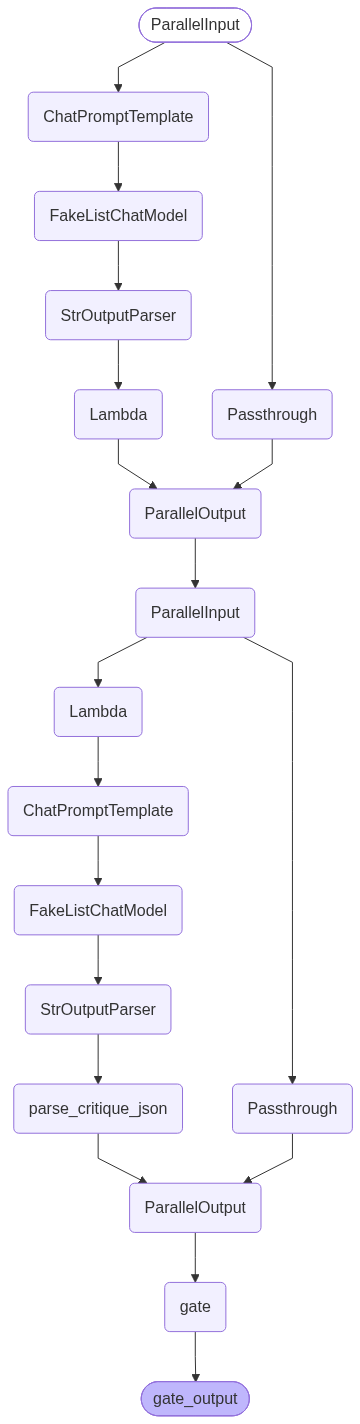

In [5]:
accepted_chain = build_chain(fake_model_for(GOOD_CRITIQUE_JSON), reviser=revise_with_evidence)
show_graph(accepted_chain, alt="Generator-Critic LCEL")


## Mock run 1: clean critique accepts

The fake generator returns the incident update and the fake critic returns a high score with no issues. The policy accepts. Notice that the trace says `generated -> critiqued -> accepted`: the critic did not decide; the policy did.

In [6]:
result = accepted_chain.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result)


decision: accepted
trace: generated -> critiqued -> accepted
score: 0.9
score evidence: none
issues: none
dropped: none
reviewed artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes.


## Mock run 2: a revision draft needs an explicit second review

The blocker makes pass 1 return `needs_revision`. The reviser creates a separate draft while preserving the artifact that was actually judged. Pass 2 starts from that draft with `build_review_chain(...)`; only its fresh critique can accept revision 1.

In [7]:
revision_chain = build_chain(
    fake_model_for(NEEDS_REVISION_CRITIQUE_JSON),
    reviser=revise_with_evidence,
)
first_pass = revision_chain.invoke({"prompt": DEFAULT_PROMPT})
print("pass 1")
print_trace(first_pass)

second_review_chain = build_review_chain(
    FakeListChatModel(responses=[GOOD_CRITIQUE_JSON]),
    reviser=revise_with_evidence,
)
second_pass = second_review_chain.invoke({"artifact": first_pass.revision_draft})
print()
print("pass 2")
print_trace(second_pass)

pass 1
decision: needs_revision
trace: generated -> critiqued -> needs_revision -> revision_drafted
score: 0.74
score evidence: incident policy requires a cited status incident
issues: ['blocker:incident_policy:sentence 2:impact claim lacks a cited source']
dropped: none
reviewed artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes.
revision draft (unreviewed): We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes. Evidence: status dashboard incident INC-42.

pass 2
decision: accepted
trace: artifact_received -> critiqued -> accepted
score: 0.9
score evidence: none
issues: none
dropped: none
reviewed artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes. Evidence: status dashboard incident INC-42.


## Mock run 3: low score without blockers still fails

A critic does not need to find a blocker to stop the artifact. Here the only issue is a warning, but the score is below the default `min_score=0.8`, so the deterministic policy still requires revision.

In [8]:
low_score_chain = build_chain(
    fake_model_for(LOW_SCORE_CRITIQUE_JSON),
    reviser=revise_with_evidence,
)
result = low_score_chain.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result)


decision: needs_revision
trace: generated -> critiqued -> needs_revision -> revision_drafted
score: 0.62
score evidence: support style rubric requires a concrete update window
issues: ['warning:support_style_guide:sentence 3:next update timing is too vague']
dropped: none
reviewed artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes.
revision draft (unreviewed): We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes. Evidence: status dashboard incident INC-42.


## Mock run 4: unsupported opinions cannot block

The critic labels a style preference as a blocker but supplies no evidence. `Critique` removes it from the actionable issue list, preserves it in `dropped_issues` for audit, and the policy accepts the artifact. A severity label alone is not evidence.

In [9]:
opinion_chain = build_chain(fake_model_for(OPINION_ONLY_CRITIQUE_JSON))
result = opinion_chain.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result)

decision: accepted
trace: generated -> critiqued -> dropped_opinions:1 -> accepted
score: 0.92
score evidence: none
issues: none
dropped: ['blocker:style_preference:body:the update feels too terse']
reviewed artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes.


## Mock run 5: malformed critic output fails closed

The critic output is invalid JSON. The parser catches that and returns an evidence-backed parser blocker with score `0.0`. A broken critic therefore takes the revision path instead of becoming an accidental approval.

In [10]:
parse_failure_chain = build_chain(
    fake_model_for(BAD_CRITIQUE_JSON),
    reviser=revise_with_evidence,
)
result = parse_failure_chain.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result)


decision: needs_revision
trace: generated -> critiqued -> needs_revision -> revision_drafted
score: 0.0
score evidence: critic output failed schema validation
issues: ['blocker:parser:critic:critic output could not be parsed: JSONDecodeError: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)']
dropped: none
reviewed artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes.
revision draft (unreviewed): We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes. Evidence: status dashboard incident INC-42.


## Real backend

The real backend uses the same `build_chain` function as the fake runs. There is no special fake/real mode flag in the pattern:

- fake run: `build_chain(FakeListChatModel(...))`
- real run: `build_chain(model)`

`get_model()` is the only boundary. If no provider key is configured, it returns `None` and the cell skips. For deterministic notebook verification, run tests with provider API keys unset rather than adding a notebook-specific mode flag.

In [11]:
model = get_model()

if model is None:
    print("No model configured — skipping real backend run. See .env.example to enable.")
else:
    try:
        real_chain = build_chain(model)
        result = real_chain.invoke({"prompt": DEFAULT_PROMPT})
        print_trace(result)
    except Exception as exc:  # noqa: BLE001
        # Provider outages, auth failures, and rate limits are reported instead
        # of crashing the tutorial. Parser failures still fail closed inside the
        # chain and show up as a needs_revision result.
        print(f"Real backend failed gracefully: {type(exc).__name__}: {exc}")


Model: ernie:ernie-5.1


decision: needs_revision
trace: generated -> critiqued -> needs_revision
score: 0.45
score evidence: Multiple unfilled template placeholders ([Date], [support email/phone], [Your Company Name]) render the message unpublishable; vague impact scope reduces trust and transparency
issues: ['blocker:Template completeness check:First paragraph, second sentence:Date placeholder [Date] is not filled in, making the incident timeline meaningless.', 'blocker:Template completeness check:Penultimate sentence:Contact information placeholder [support email/phone] is not filled in, preventing customers from reaching support.', 'blocker:Template completeness check:Sign-off line:Company name placeholder [Your Company Name] is not filled in, removing sender identity.', "warning:Incident communication best-practice rubric:First paragraph, second sentence:Impact description is vague ('some customers may have been unable') and does not quantify scope or specify affected transaction types.", 'warning:Inciden

## What to remember

- The generator creates the artifact; the critic creates evidence; the policy decides.
- The result separates the artifact that was judged from any unreviewed revision draft.
- A revision can be accepted only by an explicit `build_review_chain(...)` pass.
- Unsupported opinions remain auditable in `dropped_issues`, but cannot trigger policy.
- `FakeListChatModel` is the correct LCEL fake because responses line up with model-call order.

## Further reading

- [LangGraph version](../langgraph/tutorial.ipynb) — same pattern with explicit nodes and a conditional edge
- [Pattern README](../README.md) — design rationale and Python core implementation
- [Reference implementation guide](../../../REFERENCE_IMPL.md) — repo conventions, fake-model guidance, notebook verification commands
- [LangChain docs](https://docs.langchain.com/oss/python/langchain/overview)